In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [2]:
# PhonePe Digital Payments Case Study
# (Analyzing Transaction and Demographic Data)
# Overview: This case study involves analyzing transaction data from the financial application PhonePe along with demographic 
# data across various states and districts in India. The objective is to provide insights into transaction trends, device 
# usage, and demographic correlations, while ensuring data consistency and performing advanced analyses to uncover deeper 
# insights.
# The datasets span multiple years and quarters, providing a comprehensive view of transactions, user behavior, and 
# demographic details. Participants are expected to use their Python skills to load, explore, and analyze the data, 
# ultimately deriving meaningful insights and visualizations.

**1. DATA LOADING**

In [3]:
# Load individual sheets
file_path = r"data/phonepe/phonepe_pulse_raw_data.xlsx"
df_state_txn = pd.read_excel(file_path, sheet_name = 'State_Txn and Users')
df_state_txn_split = pd.read_excel(file_path, sheet_name = 'State_TxnSplit')
df_state_device = pd.read_excel(file_path, sheet_name = 'State_DeviceData')
df_district_txn = pd.read_excel(file_path, sheet_name = 'District_Txn and Users')
df_district_demo =  pd.read_excel(file_path, sheet_name = 'District Demographics')

**2. DATA EXPLORATION**

In [4]:
# 1.1: Load each dataset and display its structure
# 1. Load the State_Txn and Users dataset and display its first 5 rows.
# 2. Load the State_TxnSplit dataset and display its bottom 10 rows.
# 3. Load the State_DeviceData dataset and display 10 rows from the middle of the dataset.
# 4. Load the District Txn and Users dataset and display its first 10 rows and last 10 rows.
# 5. Load the District Demographics dataset and display every 10th row.

df_state_txn.head()
df_state_txn_split.tail(10)
df_state_device.iloc[len(df_state_device)//2-5:len(df_state_device)//2+5]
df_district_txn.head(10)
df_district_txn.tail(10)
df_district_demo.iloc[::10]

,State,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
0,Andaman & Nicobar Islands,2018,1,6658,1.463176e+07,2197.621091,6740,0
1,Andaman & Nicobar Islands,2018,2,11340,2.833854e+07,2498.989022,9405,0
2,Andaman & Nicobar Islands,2018,3,16265,5.555747e+07,3415.768284,12149,0
3,Andaman & Nicobar Islands,2018,4,23758,9.054834e+07,3811.277720,15222,0
4,Andaman & Nicobar Islands,2019,1,30486,1.022997e+08,3355.630147,18596,0


,State,Year,Quarter,Transaction Type,Transactions,Amount (INR),ATV (INR)
2504,West Bengal,2021,1,Peer-to-peer payments,53869075,2.022402e+11,3754.292226
2505,West Bengal,2021,1,Merchant payments,37143701,2.891834e+10,778.553104
2506,West Bengal,2021,1,Recharge & bill payments,26673733,1.133967e+10,425.124820
2507,West Bengal,2021,1,Financial Services,166727,1.754458e+08,1052.293941
2508,West Bengal,2021,1,Others,400816,2.635025e+08,657.415236
2509,West Bengal,2021,2,Peer-to-peer payments,64661051,2.308123e+11,3569.572026
2510,West Bengal,2021,2,Merchant payments,41696787,3.478787e+10,834.305703
2511,West Bengal,2021,2,Recharge & bill payments,34799709,1.333145e+10,383.090958
2512,West Bengal,2021,2,Financial Services,190537,1.864665e+08,978.636630
2513,West Bengal,2021,2,Others,549353,3.167447e+08,576.577748


,State,Year,Quarter,Brand,Registered Users,Percentage
2767,Ladakh,2021,2,OnePlus,1741,0.023198
2768,Ladakh,2021,2,Motorola,922,0.012285
2769,Ladakh,2021,2,Huawei,894,0.011912
2770,Ladakh,2021,2,Lenovo,490,0.006529
2771,Ladakh,2021,2,Others,2610,0.034778
2772,Lakshadweep,2018,1,Samsung,102,0.203593
2773,Lakshadweep,2018,1,Xiaomi,100,0.199601
2774,Lakshadweep,2018,1,Vivo,67,0.133733
2775,Lakshadweep,2018,1,Oppo,56,0.111776
2776,Lakshadweep,2018,1,Huawei,25,0.049900


,State,Year,Quarter,District,Code,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
0,Andaman & Nicobar Islands,2018,1,Nicobars,AN01,528,1.139849e+06,2158.804548,262,0
1,Andaman & Nicobar Islands,2018,1,North And Middle Andaman,AN02,442,9.316631e+05,2107.835016,632,0
2,Andaman & Nicobar Islands,2018,1,South Andaman,AN03,5688,1.256025e+07,2208.201361,5846,0
3,Andaman & Nicobar Islands,2018,2,Nicobars,AN01,1120,3.072437e+06,2743.247239,351,0
4,Andaman & Nicobar Islands,2018,2,North And Middle Andaman,AN02,825,1.317863e+06,1597.409798,911,0
5,Andaman & Nicobar Islands,2018,2,South Andaman,AN03,9395,2.394824e+07,2549.040502,8143,0
6,Andaman & Nicobar Islands,2018,3,Nicobars,AN01,1471,6.387829e+06,4342.507921,467,0
7,Andaman & Nicobar Islands,2018,3,North And Middle Andaman,AN02,1283,4.901530e+06,3820.365954,1208,0
8,Andaman & Nicobar Islands,2018,3,South Andaman,AN03,13511,4.426811e+07,3276.449742,10474,0
9,Andaman & Nicobar Islands,2018,4,Nicobars,AN01,1485,7.180859e+06,4835.595525,536,0


,State,Year,Quarter,District,Code,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
10238,West Bengal,2021,2,Murshidabad,WB14,8602251,1.999694e+10,2324.616616,1248602,16530655
10239,West Bengal,2021,2,Nadia,WB15,5524174,1.122758e+10,2032.445525,955428,13665885
10240,West Bengal,2021,2,North Twenty Four Parganas,WB16,17258291,3.041482e+10,1762.331031,2660664,37899453
10241,West Bengal,2021,2,Paschim Bardhaman,WB17,4893774,8.731263e+09,1784.157359,789026,10545670
10242,West Bengal,2021,2,Paschim Medinipur,WB18,5051834,1.030351e+10,2039.558976,856640,16201033
10243,West Bengal,2021,2,Purba Bardhaman,WB19,3920729,7.572502e+09,1931.401639,787970,12128849
10244,West Bengal,2021,2,Purba Medinipur,WB20,6418522,1.515507e+10,2361.146027,946277,15491958
10245,West Bengal,2021,2,Purulia,WB21,1895981,2.790996e+09,1472.059252,435131,8843358
10246,West Bengal,2021,2,South Twenty Four Parganas,WB22,6661813,1.339853e+10,2011.243709,1286588,19344293
10247,West Bengal,2021,2,Uttar Dinajpur,WB23,2253385,5.564221e+09,2469.272118,392388,8184990


,State,District,Headquarters,Population,Area (sq km),Density,Code,Alternate Name
0,Andhra Pradesh,Anantapur,Anantapur,4083315,19130.0,213,AP01,Anantapur
10,Andhra Pradesh,Visakhapatnam,Visakhapatnam,4288113,11161.0,384,AP10,Visakhapatnam
20,Arunachal Pradesh,Lepa Rada,Basar,0,0.0,0,AR08,Lepa Rada
30,Arunachal Pradesh,Siang,Pangin,31920,2919.0,11,AR18,Siang
40,Assam,Barpeta,Barpeta,1693622,3245.0,520,AS03,Barpeta
...,...,...,...,...,...,...,...,...
700,Chandigarh,Chandigarh,Chandigarh,1055450,114.0,9258,CH01,Chandigarh
710,Jammu & Kashmir,Jammu,Jammu,1526406,3097.0,596,JK07,Jammu
720,Jammu & Kashmir,Samba,Samba,318611,913.0,318,JK17,Samba
730,Delhi,North Delhi,Sadar Bazaar,887978,59.0,14557,DL04,North


In [5]:
# 1.2: Display basic statistics and data types for each dataset
# 1. For each dataset, display the summary statistics (mean, median, std, etc.) for numerical columns.

df_state_txn.describe()
df_state_txn_split.describe()
df_state_device.describe()
df_district_txn.describe()
df_district_demo.describe()


,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
count,504.000000,504.000000,5.040000e+02,5.030000e+02,504.000000,5.040000e+02,5.040000e+02
mean,2019.285714,2.357143,4.074000e+07,7.083332e+10,1993.471543,4.777501e+06,9.774471e+07
std,1.031181,1.109971,8.228714e+07,1.440902e+11,607.464894,6.644496e+06,2.042376e+08
min,2018.000000,1.000000,7.780000e+02,1.928611e+06,0.000000,5.010000e+02,0.000000e+00
25%,2018.000000,1.000000,5.925578e+05,1.167157e+09,1598.910667,1.574202e+05,0.000000e+00
50%,2019.000000,2.000000,6.217487e+06,1.051605e+10,1861.380589,1.747914e+06,2.930574e+06
75%,2020.000000,3.000000,4.363675e+07,6.947045e+10,2259.087924,7.320945e+06,8.615022e+07
max,2021.000000,4.000000,5.736165e+08,1.027958e+12,3938.733850,3.966470e+07,1.208084e+09


,Year,Quarter,Transactions,Amount (INR),ATV (INR)
count,2514.000000,2514.000000,2.514000e+03,2.514000e+03,2514.000000
mean,2019.286794,2.358393,8.167446e+06,1.443978e+10,1349.927929
std,1.030807,1.109251,2.423645e+07,5.995054e+10,1534.866221
min,2018.000000,1.000000,2.000000e+00,3.439721e+01,17.198606
25%,2018.000000,1.000000,2.788075e+04,1.762412e+07,385.735827
50%,2019.000000,2.000000,2.687980e+05,1.901189e+08,720.940406
75%,2020.000000,3.000000,3.683230e+06,2.661248e+09,1352.790116
max,2021.000000,4.000000,2.795990e+08,8.721520e+11,7767.539936


,Year,Quarter,Registered Users,Percentage
count,5544.000000,5544.000000,5.544000e+03,5544.000000
mean,2019.285714,2.357143,4.343183e+05,0.090909
std,1.030250,1.108970,9.056069e+05,0.083095
min,2018.000000,1.000000,1.000000e+01,0.006373
25%,2018.000000,1.000000,8.055750e+03,0.021588
50%,2019.000000,2.000000,7.442250e+04,0.056914
75%,2020.000000,3.000000,3.978875e+05,0.143626
max,2021.000000,4.000000,9.764252e+06,0.478367


,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
count,10248.000000,10248.000000,1.024800e+04,1.024800e+04,10244.000000,1.024800e+04,1.024800e+04
mean,2019.285714,2.357143,2.003607e+06,3.542311e+09,1909.796545,2.349591e+05,4.807117e+06
std,1.030208,1.108924,9.613466e+06,1.473154e+10,600.943349,4.605978e+05,1.562541e+07
min,2018.000000,1.000000,0.000000e+00,0.000000e+00,84.944283,2.200000e+01,0.000000e+00
25%,2018.000000,1.000000,1.031418e+05,1.756668e+08,1554.589051,3.619550e+04,0.000000e+00
50%,2019.000000,2.000000,3.763065e+05,6.784562e+08,1863.135530,1.067640e+05,6.403025e+05
75%,2020.000000,3.000000,1.272815e+06,2.377256e+09,2203.083552,2.573165e+05,4.346320e+06
max,2021.000000,4.000000,3.487128e+08,4.444224e+11,11209.980550,1.060461e+07,5.544197e+08


,Population,Area (sq km),Density
count,7.420000e+02,742.000000,742.000000
mean,1.668555e+06,4395.373120,838.512129
std,1.458849e+06,4254.676124,2754.406896
min,0.000000e+00,0.000000,0.000000
25%,6.530815e+05,2039.750000,198.000000
50%,1.322359e+06,3402.500000,353.000000
75%,2.297440e+06,5432.750000,686.250000
max,1.008285e+07,45652.000000,36155.000000


In [6]:
# 2. Display the data types of each column in each dataset.

df_state_txn.dtypes
df_state_txn_split.dtypes
df_state_device.dtypes
df_district_txn.dtypes
df_district_demo.dtypes


State                object
Year                  int64
Quarter               int64
Transactions          int64
Amount (INR)        float64
ATV (INR)           float64
Registered Users      int64
App Opens             int64
dtype: object

State                object
Year                  int64
Quarter               int64
Transaction Type     object
Transactions          int64
Amount (INR)        float64
ATV (INR)           float64
dtype: object

State                object
Year                  int64
Quarter               int64
Brand                object
Registered Users      int64
Percentage          float64
dtype: object

State                object
Year                  int64
Quarter               int64
District             object
Code                 object
Transactions          int64
Amount (INR)        float64
ATV (INR)           float64
Registered Users      int64
App Opens             int64
dtype: object

State              object
District           object
Headquarters       object
Population          int64
Area (sq km)      float64
Density             int64
Code               object
Alternate Name     object
dtype: object

**3. HANDLE MISSING DATA**

In [7]:
# 1.3: Check for missing values
# 1. Identify any missing values in each dataset.

df_state_txn.isnull().sum()
df_state_txn_split.isnull().sum()
df_state_device.isnull().sum()
df_district_txn.isnull().sum()
df_district_demo.isnull().sum()

State               0
Year                0
Quarter             0
Transactions        0
Amount (INR)        1
ATV (INR)           0
Registered Users    0
App Opens           0
dtype: int64

State               0
Year                0
Quarter             0
Transaction Type    0
Transactions        0
Amount (INR)        0
ATV (INR)           0
dtype: int64

State               0
Year                0
Quarter             0
Brand               0
Registered Users    0
Percentage          0
dtype: int64

State                0
Year                 0
Quarter              0
District             0
Code                28
Transactions         0
Amount (INR)         0
ATV (INR)            4
Registered Users     0
App Opens            0
dtype: int64

State             0
District          0
Headquarters      0
Population        0
Area (sq km)      0
Density           0
Code              0
Alternate Name    0
dtype: int64

In [8]:
# 2. Calculate the percentage of missing values for each column that has missing values.

(df_district_demo.isna().mean()) * 100
(df_district_txn.isna().mean()) * 100
(df_state_device.isna().mean()) * 100
(df_state_txn.isna().mean()) * 100
(df_state_txn_split.isna().mean()) * 100

State             0.0
District          0.0
Headquarters      0.0
Population        0.0
Area (sq km)      0.0
Density           0.0
Code              0.0
Alternate Name    0.0
dtype: float64

State               0.000000
Year                0.000000
Quarter             0.000000
District            0.000000
Code                0.273224
Transactions        0.000000
Amount (INR)        0.000000
ATV (INR)           0.039032
Registered Users    0.000000
App Opens           0.000000
dtype: float64

State               0.0
Year                0.0
Quarter             0.0
Brand               0.0
Registered Users    0.0
Percentage          0.0
dtype: float64

State               0.000000
Year                0.000000
Quarter             0.000000
Transactions        0.000000
Amount (INR)        0.198413
ATV (INR)           0.000000
Registered Users    0.000000
App Opens           0.000000
dtype: float64

State               0.0
Year                0.0
Quarter             0.0
Transaction Type    0.0
Transactions        0.0
Amount (INR)        0.0
ATV (INR)           0.0
dtype: float64

In [9]:
# 3. Highlight which column has the highest percentage of missing values in each dataset.

df_state_txn.isnull().sum().idxmax()
df_state_txn_split.isnull().sum().idxmax()
df_state_device.isnull().sum().idxmax()
df_district_txn.isnull().sum().idxmax()
df_district_demo.isnull().sum().idxmax()

'Amount (INR)'

'State'

'State'

'Code'

'State'

In [10]:
# 1.4: Create a summary
# 1. Calculate the total number of states and the total number of districts.

df_state_device['State'].nunique()
df_district_txn['State'].nunique()
df_district_txn['District'].nunique()

36

36

723

In [11]:
# 2. Identify the state with the highest number of districts.

df_district_demo.groupby('State')['District'].nunique().sort_values(ascending=False)
df_district_demo.groupby('State')['District'].nunique().idxmax()
df_district_demo.groupby('State')['District'].nunique().max()

State
Uttar Pradesh                           75
Madhya Pradesh                          55
Tamil Nadu                              38
Bihar                                   38
Maharashtra                             36
Assam                                   34
Rajasthan                               33
Gujarat                                 33
Telangana                               33
Karnataka                               31
Odisha                                  30
Chhattisgarh                            28
Arunachal Pradesh                       25
Jharkhand                               24
Punjab                                  23
West Bengal                             23
Haryana                                 22
Jammu & Kashmir                         20
Manipur                                 16
Kerala                                  14
Andhra Pradesh                          13
Uttarakhand                             13
Himachal Pradesh                        12
Nagal

'Uttar Pradesh'

75

**4. DATA ANALYSIS**

In [12]:
# Task 2: Exploratory Data Analysis (EDA)
# 2.1: Analyze transaction trends over the years for each state
# 1. Calculate the total number of transactions and total transaction amount for each state over the years. Display the 
# results in a tabular format.
df_state_txn.groupby(["State","Year"])[["Transactions","Amount (INR)"]].sum().reset_index()

,State,Year,Transactions,Amount (INR)
0,Andaman & Nicobar Islands,2018,58021,1.890761e+08
1,Andaman & Nicobar Islands,2019,133104,4.734648e+08
2,Andaman & Nicobar Islands,2020,446274,1.296423e+09
3,Andaman & Nicobar Islands,2021,586166,1.682854e+09
4,Andhra Pradesh,2018,77779112,1.220720e+11
...,...,...,...,...
139,Uttarakhand,2021,44608834,7.727901e+10
140,West Bengal,2018,120011635,1.115887e+11
141,West Bengal,2019,257900590,2.660145e+11
142,West Bengal,2020,304222327,5.527316e+11


In [13]:
# 2. Identify the top 5 states with the highest transaction volumes and the top 5 states with the lowest transaction volumes. 
# Display the results.
df_state_txn.groupby(['State'])['Transactions'].sum().idxmax()
df_state_txn.groupby(['State'])['Transactions'].sum().idxmin()
df_state_txn.groupby(['State'])['Transactions'].sum().nlargest(5)
df_state_txn.groupby(['State'])['Transactions'].sum().nsmallest(5)

'Karnataka'

'Lakshadweep'

State
Karnataka         2981044533
Maharashtra       2833670154
Telangana         2347430243
Andhra Pradesh    1781091169
Rajasthan         1382918930
Name: Transactions, dtype: int64

State
Lakshadweep                    71610
Andaman & Nicobar Islands    1223565
Ladakh                       1880109
Mizoram                      2162776
Meghalaya                    5648913
Name: Transactions, dtype: int64

In [14]:
# 2.2: Identify the most common transaction types in each state and quarter
# 1. For each state and quarter, determine the most frequent transaction type. Display the results in a tabular format.

top_idx = df_state_txn_split.groupby(['State', 'Year', 'Quarter'])['Transactions'].idxmax()
df_state_txn_split.loc[top_idx]

,State,Year,Quarter,Transaction Type,Transactions,Amount (INR),ATV (INR)
0,Andaman & Nicobar Islands,2018,1,Recharge & bill payments,4200,1.845307e+06,439.358921
5,Andaman & Nicobar Islands,2018,2,Recharge & bill payments,6735,2.320945e+06,344.609463
10,Andaman & Nicobar Islands,2018,3,Recharge & bill payments,8636,4.343505e+06,502.953320
15,Andaman & Nicobar Islands,2018,4,Recharge & bill payments,11517,5.450550e+06,473.261224
20,Andaman & Nicobar Islands,2019,1,Recharge & bill payments,15263,6.611460e+06,433.169093
...,...,...,...,...,...,...,...
2489,West Bengal,2020,2,Peer-to-peer payments,24855687,8.498400e+10,3419.096979
2494,West Bengal,2020,3,Peer-to-peer payments,37556349,1.331207e+11,3544.558502
2499,West Bengal,2020,4,Peer-to-peer payments,46437233,1.663919e+11,3583.156529
2504,West Bengal,2021,1,Peer-to-peer payments,53869075,2.022402e+11,3754.292226


In [15]:
# 2.3: Determine the device brand with the highest number of registered users in each state
# 1. Identify the device brand with the highest number of registered users in each state. Display the results in a tabular format.

users = df_state_device.groupby(['State', 'Brand'])['Registered Users'].sum().reset_index()
rows = users.groupby(['State'])['Registered Users'].idxmax()
users.loc[rows]

,State,Brand,Registered Users
11,Andaman & Nicobar Islands,Xiaomi,97889
22,Andhra Pradesh,Xiaomi,40061549
34,Arunachal Pradesh,Xiaomi,437803
46,Assam,Xiaomi,6979357
60,Bihar,Xiaomi,33721314
73,Chandigarh,Xiaomi,896628
85,Chhattisgarh,Xiaomi,8763373
98,Dadra & Nagar Haveli and Daman & Diu,Xiaomi,638834
109,Delhi,Xiaomi,24114984
120,Goa,Xiaomi,1208672


In [16]:

df_district_demo.head()

,State,District,Headquarters,Population,Area (sq km),Density,Code,Alternate Name
0,Andhra Pradesh,Anantapur,Anantapur,4083315,19130.0,213,AP01,Anantapur
1,Andhra Pradesh,Chittoor,Chittoor,4170468,15152.0,275,AP02,Chittoor
2,Andhra Pradesh,East Godavari,Kakinada,5151549,10807.0,477,AP03,East Godavari
3,Andhra Pradesh,Guntur,Guntur,4889230,11391.0,429,AP04,Guntur
4,Andhra Pradesh,YSR,Kadapa,2884524,15359.0,188,AP13,YSR


In [17]:
# 2.4: Create a list of the top district per state based on population
# 1. For each state, identify the district with the highest population. Display the results in a tabular format.
df = df_district_demo.groupby(['State','District'])['Population'].sum().reset_index()
result=df.loc[df.groupby('State')['Population'].idxmax()].sort_values(by=['Population'],ascending=False)
result

,State,District,Population
734,West Bengal,North 24 Parganas,10082852
272,Karnataka,Bangalore Urban,9588910
397,Maharashtra,Pune,9426959
158,Gujarat,Ahmedabad,7208200
554,Tamil Nadu,Chennai,7139882
530,Rajasthan,Jaipur,6663971
633,Uttar Pradesh,Allahabad,5959798
100,Bihar,Patna,5772804
5,Andhra Pradesh,East Godavari,5151549
308,Kerala,Malappuram,4110956


<Figure size 1600x900 with 0 Axes>

<Axes: xlabel='State', ylabel='Population'>

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35],
 [Text(0, 0, 'West Bengal'),
  Text(1, 0, 'Karnataka'),
  Text(2, 0, 'Maharashtra'),
  Text(3, 0, 'Gujarat'),
  Text(4, 0, 'Tamil Nadu'),
  Text(5, 0, 'Rajasthan'),
  Text(6, 0, 'Uttar Pradesh'),
  Text(7, 0, 'Bihar'),
  Text(8, 0, 'Andhra Pradesh'),
  Text(9, 0, 'Kerala'),
  Text(10, 0, 'Telangana'),
  Text(11, 0, 'Delhi'),
  Text(12, 0, 'Odisha'),
  Text(13, 0, 'Punjab'),
  Text(14, 0, 'Madhya Pradesh'),
  Text(15, 0, 'Jharkhand'),
  Text(16, 0, 'Assam'),
  Text(17, 0, 'Chhattisgarh'),
  Text(18, 0, 'Uttarakhand'),
  Text(19, 0, 'Haryana'),
  Text(20, 0, 'Jammu & Kashmir'),
  Text(21, 0, 'Himachal Pradesh'),
  Text(22, 0, 'Chandigarh'),
  Text(23, 0, 'Puducherry'),
  Text(24, 0, 'Tripura'),
  Text(25, 0, 'Meghalaya'),
  Text(26, 0, 'Goa'),
  Text(27, 0, 'Manipur'),
  Text(28, 0, '

Text(0.5, 1.0, 'District with Highest Population in Each State')

Text(0.5, 0, 'State')

Text(0, 0.5, 'Population')

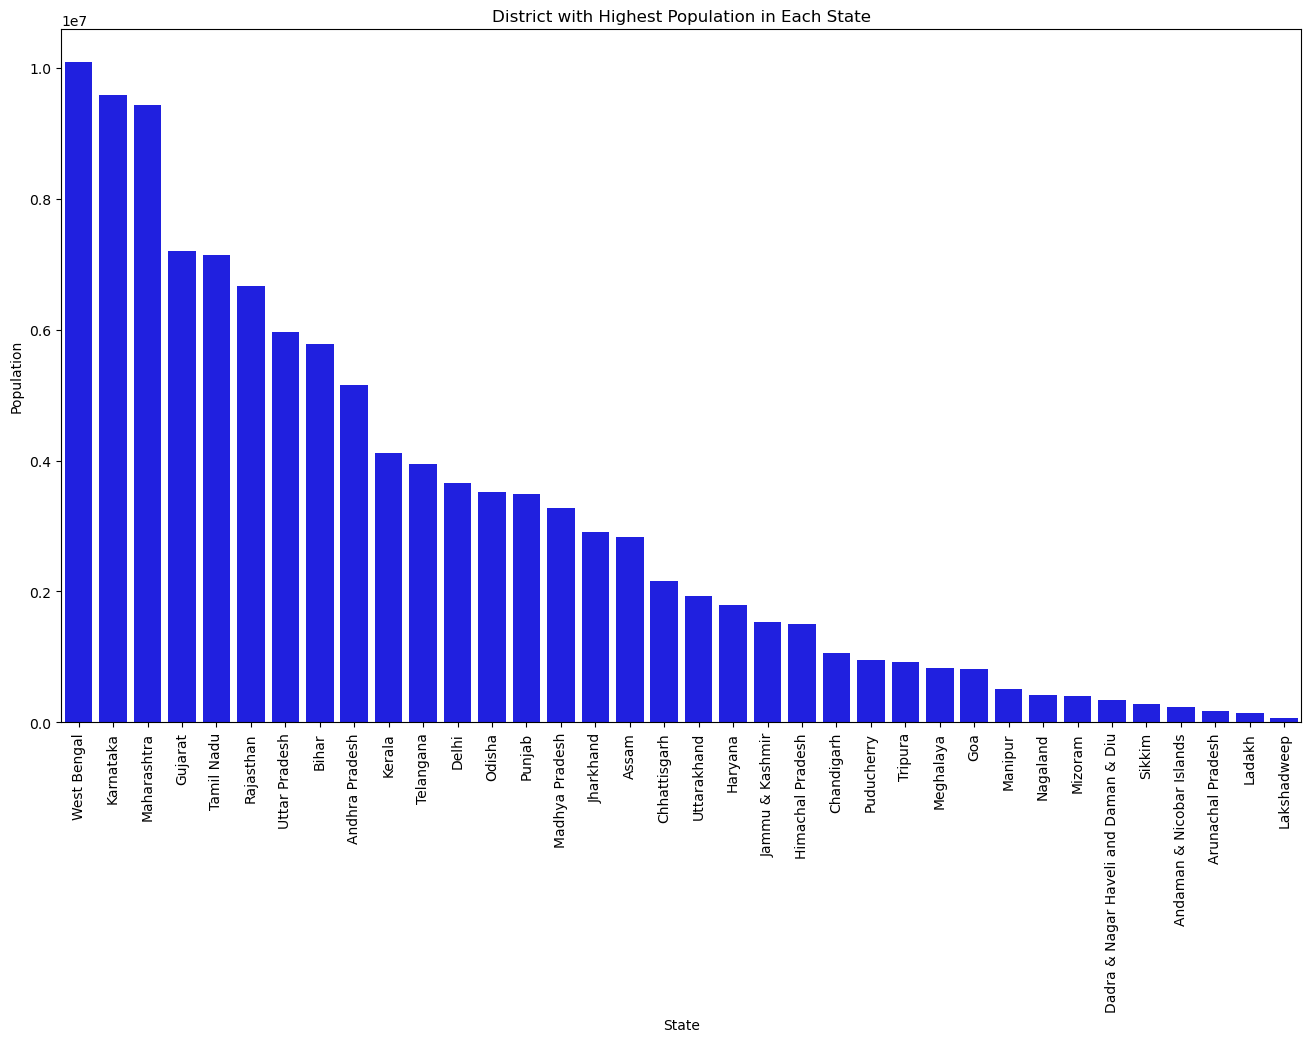

In [18]:
# 2. Create a column chart depicting the district with the highest population for each state.
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(16,9))
sns.barplot(data=result, x='State', y='Population',color='blue')
plt.xticks(rotation=90)
plt.title('District with Highest Population in Each State')
plt.xlabel('State')
plt.ylabel('Population')
plt.show()

In [19]:
# 2.5: Calculate the average transaction value (ATV) for each state
# 1. Compute the average transaction value for each state. Display the results in a tabular format.
# 2. Identify the top 5 states with the highest ATV and the top 5 states with the lowest ATV. Display the results.

avg_transactions = df_state_txn.groupby('State')[['Transactions','Amount (INR)']].sum().reset_index()
avg_transactions['avg_transaction_per_user'] = avg_transactions['Amount (INR)']/avg_transactions['Transactions']
avg_transactions

avg_transactions.nlargest(5, columns = 'avg_transaction_per_user')
avg_transactions.nsmallest(5, columns = 'avg_transaction_per_user')

,State,Transactions,Amount (INR),avg_transaction_per_user
0,Andaman & Nicobar Islands,1223565,3.641818e+09,2976.399178
1,Andhra Pradesh,1781091169,3.187847e+12,1789.828350
2,Arunachal Pradesh,8043799,2.225183e+10,2766.333539
3,Assam,123577981,2.814087e+11,2277.175192
4,Bihar,713643889,1.639579e+12,2297.474906
5,Chandigarh,25516542,5.371208e+10,2104.990740
6,Chhattisgarh,241908549,4.156353e+11,1718.150602
7,Dadra & Nagar Haveli and Daman & Diu,12462185,1.865878e+10,1497.232192
8,Delhi,1011031124,1.649942e+12,1631.940078
9,Goa,24481604,4.427187e+10,1808.372977


,State,Transactions,Amount (INR),avg_transaction_per_user
17,Ladakh,1880109,6.606978e+09,3514.146494
0,Andaman & Nicobar Islands,1223565,3.641818e+09,2976.399178
23,Mizoram,2162776,6.317141e+09,2920.848685
21,Manipur,12318043,3.579325e+10,2905.757931
24,Nagaland,5864977,1.638757e+10,2794.140997


,State,Transactions,Amount (INR),avg_transaction_per_user
15,Karnataka,2981044533,4.361396e+12,1463.042846
7,Dadra & Nagar Haveli and Daman & Diu,12462185,1.865878e+10,1497.232192
20,Maharashtra,2833670154,4.290995e+12,1514.288897
35,West Bengal,942286041,1.452707e+12,1541.683482
8,Delhi,1011031124,1.649942e+12,1631.940078


In [20]:
# 2.6: Analyze app usage trends
# 1. Calculate the total number of app opens over the years and quarters for each state. Display the results in a tabular format.

app_opens = df_state_txn.groupby(['State', 'Year', 'Quarter'])['App Opens'].sum().reset_index()
app_opens

,State,Year,Quarter,App Opens
0,Andaman & Nicobar Islands,2018,1,0
1,Andaman & Nicobar Islands,2018,2,0
2,Andaman & Nicobar Islands,2018,3,0
3,Andaman & Nicobar Islands,2018,4,0
4,Andaman & Nicobar Islands,2019,1,0
...,...,...,...,...
499,West Bengal,2020,2,198589332
500,West Bengal,2020,3,246554831
501,West Bengal,2020,4,291721919
502,West Bengal,2021,1,316832674


<Figure size 1000x500 with 0 Axes>

Text(0.5, 1.0, 'App Opens Trend Over Time in Karnataka')

Text(0.5, 0, 'Year and Quarter')

Text(0, 0.5, 'Number of App Opens')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
 [Text(0, 0, '2018-01'),
  Text(1, 0, '2018-02'),
  Text(2, 0, '2018-03'),
  Text(3, 0, '2018-04'),
  Text(4, 0, '2019-01'),
  Text(5, 0, '2019-02'),
  Text(6, 0, '2019-03'),
  Text(7, 0, '2019-04'),
  Text(8, 0, '2020-01'),
  Text(9, 0, '2020-02'),
  Text(10, 0, '2020-03'),
  Text(11, 0, '2020-04'),
  Text(12, 0, '2021-01'),
  Text(13, 0, '2021-02')])

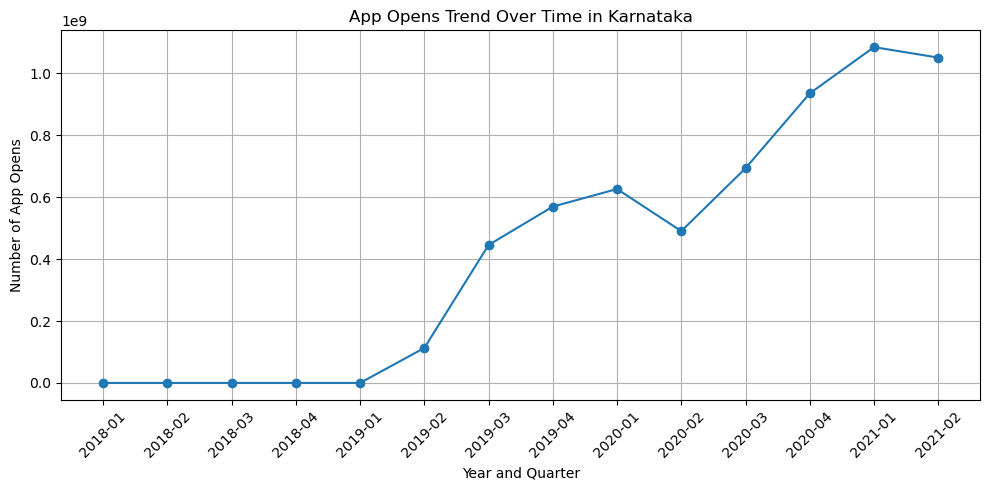

In [21]:
# 2. Identify trends in app usage by creating a line plot showing the number of app opens over time for a selected state.
selected_state = 'Karnataka'
app_opens  = app_opens.sort_values(['Year', 'Quarter'])
app_usage = app_opens[app_opens["State"] == selected_state].copy()
app_usage['Time'] = app_opens['Year'].astype(str)  + '-0' +  app_usage['Quarter'].astype(str)
plt.figure(figsize = (10, 5))
plt.plot(app_usage["Time"], app_usage["App Opens"], marker="o", linestyle="-")
plt.title(f"App Opens Trend Over Time in {selected_state}")
plt.xlabel("Year and Quarter")
plt.ylabel("Number of App Opens")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

<Figure size 1000x500 with 0 Axes>

Text(0.5, 1.0, 'App Opens Trend Over Time in West Bengal')

Text(0.5, 0, 'Year and Quarter')

Text(0, 0.5, 'Number of App Opens')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
 [Text(0, 0, '2018-01'),
  Text(1, 0, '2018-02'),
  Text(2, 0, '2018-03'),
  Text(3, 0, '2018-04'),
  Text(4, 0, '2019-01'),
  Text(5, 0, '2019-02'),
  Text(6, 0, '2019-03'),
  Text(7, 0, '2019-04'),
  Text(8, 0, '2020-01'),
  Text(9, 0, '2020-02'),
  Text(10, 0, '2020-03'),
  Text(11, 0, '2020-04'),
  Text(12, 0, '2021-01'),
  Text(13, 0, '2021-02')])

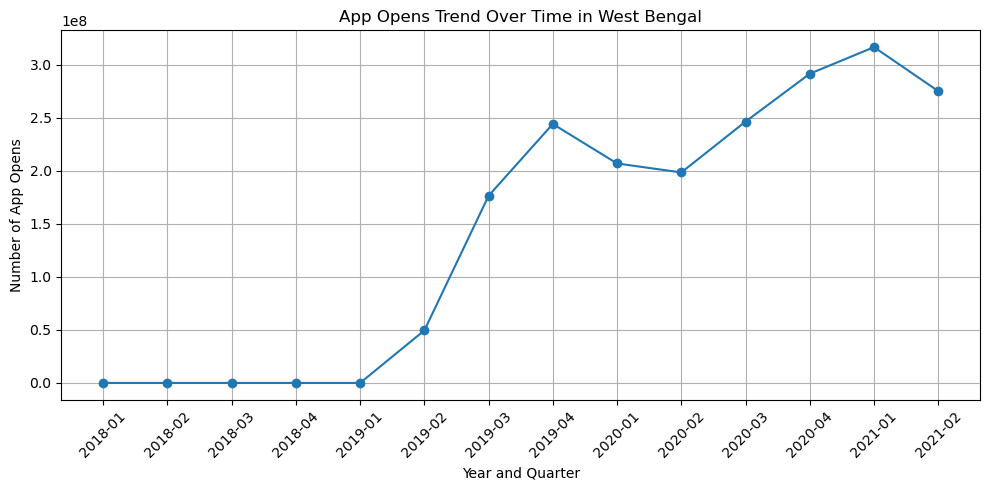

In [22]:
selected_state = 'West Bengal'
app_opens  = app_opens.sort_values(['Year', 'Quarter'])
app_usage = app_opens[app_opens["State"] == selected_state].copy()
app_usage['Time'] = app_opens['Year'].astype(str)  + '-0' +  app_usage['Quarter'].astype(str)
plt.figure(figsize = (10, 5))
plt.plot(app_usage["Time"], app_usage["App Opens"], marker="o", linestyle="-")
plt.title(f"App Opens Trend Over Time in {selected_state}")
plt.xlabel("Year and Quarter")
plt.ylabel("Number of App Opens")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

<Figure size 1000x500 with 0 Axes>

Text(0.5, 1.0, 'App Opens Trend Over Time in Rajasthan')

Text(0.5, 0, 'Year and Quarter')

Text(0, 0.5, 'Number of App Opens')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
 [Text(0, 0, '2018-01'),
  Text(1, 0, '2018-02'),
  Text(2, 0, '2018-03'),
  Text(3, 0, '2018-04'),
  Text(4, 0, '2019-01'),
  Text(5, 0, '2019-02'),
  Text(6, 0, '2019-03'),
  Text(7, 0, '2019-04'),
  Text(8, 0, '2020-01'),
  Text(9, 0, '2020-02'),
  Text(10, 0, '2020-03'),
  Text(11, 0, '2020-04'),
  Text(12, 0, '2021-01'),
  Text(13, 0, '2021-02')])

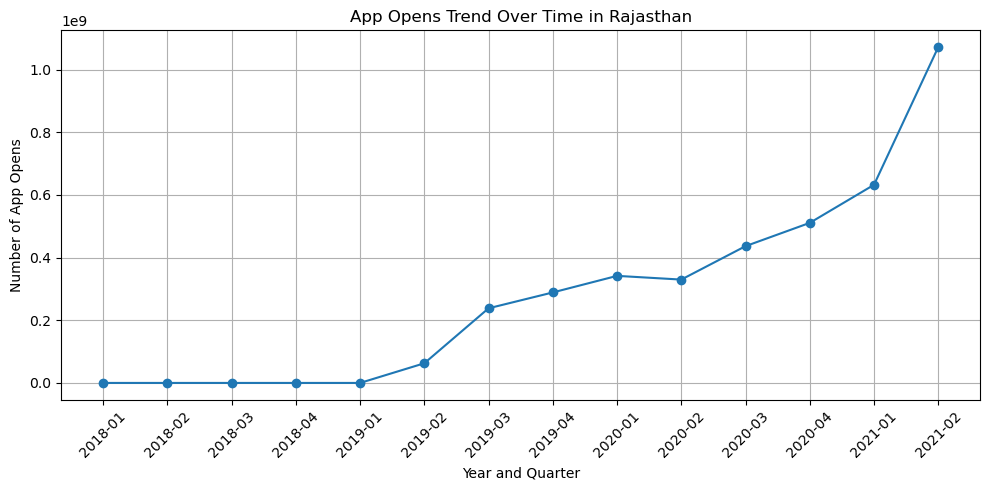

In [23]:
selected_state = 'Rajasthan'
app_opens  = app_opens.sort_values(['Year', 'Quarter'])
app_usage = app_opens[app_opens["State"] == selected_state].copy()
app_usage['Time'] = app_opens['Year'].astype(str)  + '-0' +  app_usage['Quarter'].astype(str)
plt.figure(figsize = (10, 5))
plt.plot(app_usage["Time"], app_usage["App Opens"], marker="o", linestyle="-")
plt.title(f"App Opens Trend Over Time in {selected_state}")
plt.xlabel("Year and Quarter")
plt.ylabel("Number of App Opens")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [24]:
# 2.7: Distribution of transaction types
# 1. Create a bar chart showing the distribution of different transaction types for each state for the most recent quarter in the dataset.

df_state_txn_split['YYYYQQ'] = (df_state_txn_split['Year'].astype(str) + '0'+ df_state_txn_split['Quarter'].astype(str)).astype(int)
rows = df_state_txn_split.groupby(['State', 'Transaction Type'])['YYYYQQ'].idxmax()

df_sub = df_state_txn_split.loc[rows]
df_sub

,State,Year,Quarter,Transaction Type,Transactions,Amount (INR),ATV (INR),YYYYQQ
68,Andaman & Nicobar Islands,2021,2,Financial Services,960,2.038522e+06,2123.459910,202102
67,Andaman & Nicobar Islands,2021,2,Merchant payments,85143,1.037074e+08,1218.037989,202102
69,Andaman & Nicobar Islands,2021,2,Others,1628,1.327080e+06,815.159740,202102
65,Andaman & Nicobar Islands,2021,2,Peer-to-peer payments,132772,7.483820e+08,5636.595402,202102
66,Andaman & Nicobar Islands,2021,2,Recharge & bill payments,120911,4.369196e+07,361.356380,202102
...,...,...,...,...,...,...,...,...
2512,West Bengal,2021,2,Financial Services,190537,1.864665e+08,978.636630,202102
2510,West Bengal,2021,2,Merchant payments,41696787,3.478787e+10,834.305703,202102
2513,West Bengal,2021,2,Others,549353,3.167447e+08,576.577748,202102
2509,West Bengal,2021,2,Peer-to-peer payments,64661051,2.308123e+11,3569.572026,202102


<Figure size 1000x600 with 0 Axes>

C:\Users\acer\AppData\Local\Temp\ipykernel_17980\1562247583.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Transaction Type", y="Transactions", data=state_txn_types, palette="viridis")


<Axes: xlabel='Transaction Type', ylabel='Transactions'>

Text(0.5, 1.0, 'Distribution of Transaction Types in Rajasthan 202102')

Text(0.5, 0, 'Transaction Type')

Text(0, 0.5, 'Number of Transactions')

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Financial Services'),
  Text(1, 0, 'Merchant payments'),
  Text(2, 0, 'Others'),
  Text(3, 0, 'Peer-to-peer payments'),
  Text(4, 0, 'Recharge & bill payments')])

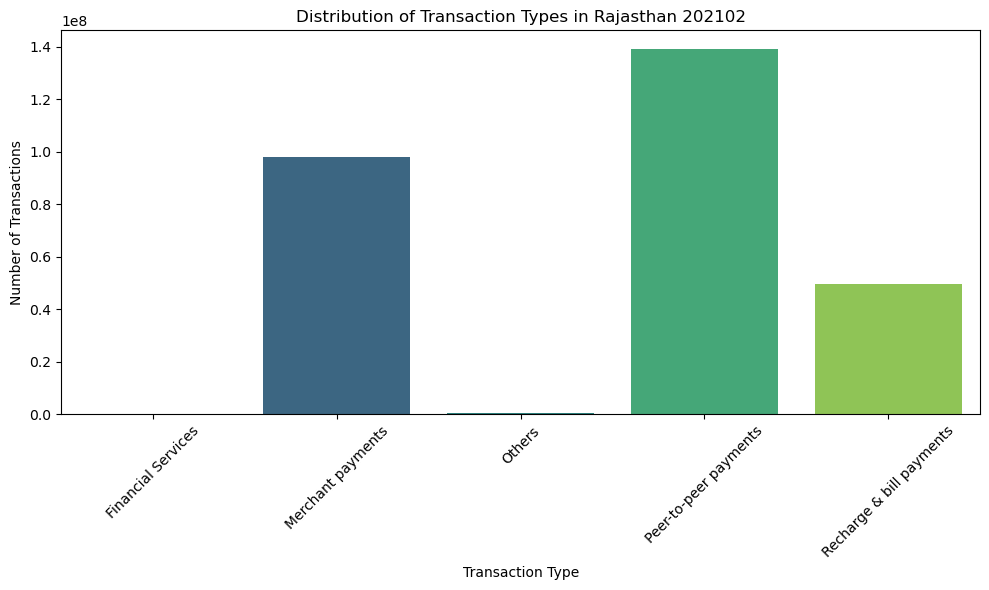

In [25]:
selected_state = "Rajasthan"
state_txn_types = df_sub[df_sub["State"] == selected_state]

plt.figure(figsize=(10, 6))
sns.barplot(x="Transaction Type", y="Transactions", data=state_txn_types, palette="viridis")
plt.title(f"Distribution of Transaction Types in {selected_state} {df_sub['YYYYQQ'].max()}")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

C:\Users\acer\AppData\Local\Temp\ipykernel_17980\2221407934.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Transaction Type", y="Transactions", data=state_txn_types, palette="viridis")


<Axes: xlabel='Transaction Type', ylabel='Transactions'>

Text(0.5, 1.0, 'Distribution of Transaction Types in West Bengal 202102')

Text(0.5, 0, 'Transaction Type')

Text(0, 0.5, 'Number of Transactions')

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Financial Services'),
  Text(1, 0, 'Merchant payments'),
  Text(2, 0, 'Others'),
  Text(3, 0, 'Peer-to-peer payments'),
  Text(4, 0, 'Recharge & bill payments')])

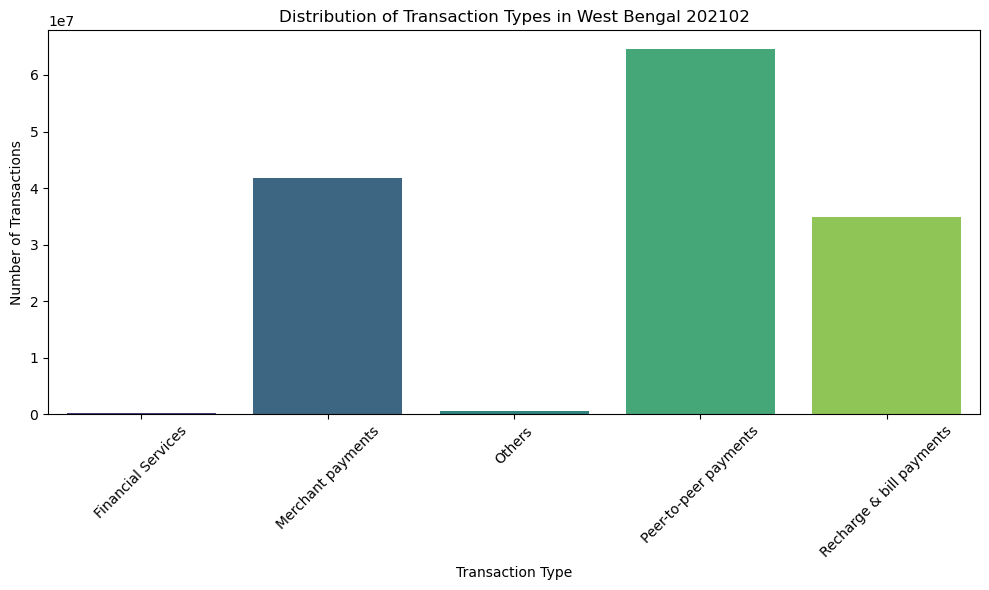

In [26]:
selected_state = "West Bengal"
state_txn_types = df_sub[df_sub["State"] == selected_state]

plt.figure(figsize=(10, 6))
sns.barplot(x="Transaction Type", y="Transactions", data=state_txn_types, palette="viridis")
plt.title(f"Distribution of Transaction Types in {selected_state} {df_sub['YYYYQQ'].max()}")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

C:\Users\acer\AppData\Local\Temp\ipykernel_17980\1467016459.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Transaction Type", y="Transactions", data=state_txn_types, palette="viridis")


<Axes: xlabel='Transaction Type', ylabel='Transactions'>

Text(0.5, 1.0, 'Distribution of Transaction Types in Maharashtra 202102')

Text(0.5, 0, 'Transaction Type')

Text(0, 0.5, 'Number of Transactions')

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Financial Services'),
  Text(1, 0, 'Merchant payments'),
  Text(2, 0, 'Others'),
  Text(3, 0, 'Peer-to-peer payments'),
  Text(4, 0, 'Recharge & bill payments')])

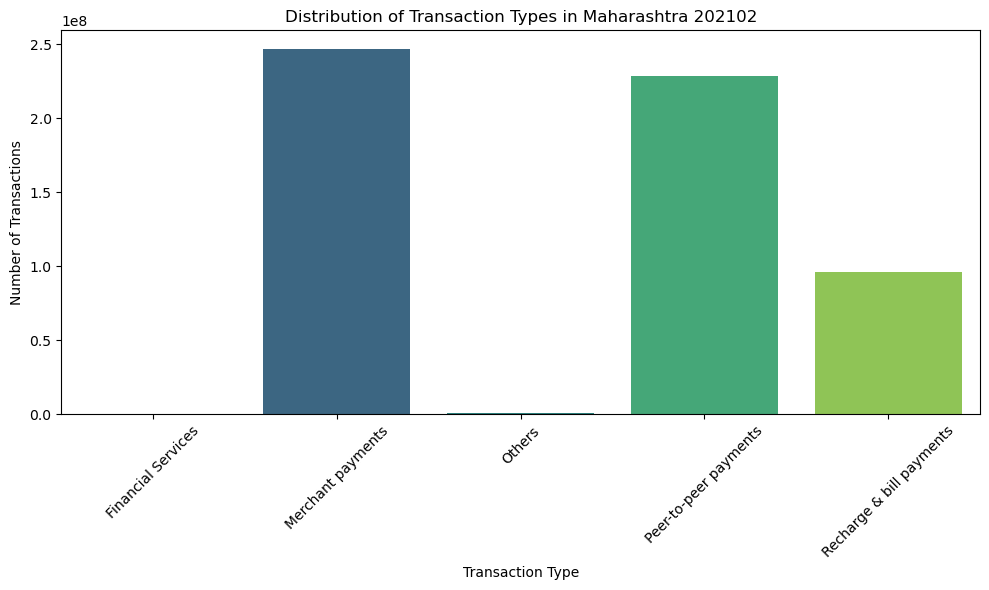

In [27]:
selected_state = "Maharashtra"
state_txn_types = df_sub[df_sub["State"] == selected_state]

plt.figure(figsize=(10, 6))
sns.barplot(x="Transaction Type", y="Transactions", data=state_txn_types, palette="viridis")
plt.title(f"Distribution of Transaction Types in {selected_state} {df_sub['YYYYQQ'].max()}")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [28]:
# 2.8: Find unique mapping between district name and district code
# 1. Identify the unique mapping between district names and district codes from the dataset. 
# [hint: you can use drop_duplicates()]
# 2. Create a CSV file containing the unique district name and district code mappings.
# 3. Export the CSV file.

# Get unique mapping of district names and codes
district_code_mapping = df_district_demo[["State", "District", "Code"]].drop_duplicates()
district_code_mapping
district_code_mapping.to_csv("district_code_mapping.csv", index=False)
print("CSV file 'district_code_mapping.csv' has been successfully created and saved.")

,State,District,Code
0,Andhra Pradesh,Anantapur,AP01
1,Andhra Pradesh,Chittoor,AP02
2,Andhra Pradesh,East Godavari,AP03
3,Andhra Pradesh,Guntur,AP04
4,Andhra Pradesh,YSR,AP13
...,...,...,...
737,Delhi,West Delhi,DL11
738,Puducherry,Karaikal,PY01
739,Puducherry,Mahé,PY02
740,Puducherry,Puducherry,PY03


CSV file 'district_code_mapping.csv' has been successfully created and saved.


In [29]:
pd.read_csv(r'C:\Users\acer\district_code_mapping.csv')

,State,District,Code
0,Andhra Pradesh,Anantapur,AP01
1,Andhra Pradesh,Chittoor,AP02
2,Andhra Pradesh,East Godavari,AP03
3,Andhra Pradesh,Guntur,AP04
4,Andhra Pradesh,YSR,AP13
...,...,...,...
737,Delhi,West Delhi,DL11
738,Puducherry,Karaikal,PY01
739,Puducherry,Mahé,PY02
740,Puducherry,Puducherry,PY03


In [30]:
# Task 3: Data Quality Checks
# 3.1: Ensure data consistency across state and district levels
# 1. For each state, calculate the total number of transactions, total transaction amount, and total registered users 
# by summing up the values from the district level data.

df_district = df_district_txn.groupby(['State']).agg(district_transactions = ('Transactions', 'sum'), 
                                      district_transaction_amt = ('Amount (INR)', 'sum'),
                                      district_reg_users = ('Registered Users', 'sum')).reset_index()

# Calculate the total number of transactions, total transaction amount, 
# and total registered users in each state by summing up the values from the State level data

df_state = df_state_txn.groupby(['State']).agg(state_transactions = ('Transactions', 'sum'), 
                                      state_transaction_amt = ('Amount (INR)', 'sum'),
                                      state_reg_users = ('Registered Users', 'sum')).reset_index()

df_combined = df_state.merge(df_district, how = 'left', on = ['State'])

In [31]:
(df_combined['state_transactions'] == df_combined['district_transactions']).mean()
(df_combined['state_transaction_amt'] == df_combined['district_transaction_amt']).mean()
(df_combined['state_reg_users'] == df_combined['district_reg_users']).mean()

np.float64(1.0)

np.float64(0.027777777777777776)

np.float64(1.0)

In [32]:
# 3. Display any discrepancies found between the district-level and state-level data.
discrepancies=df_combined[
    (df_combined['state_transactions'] != df_combined['district_transactions']) |
    (df_combined['state_transaction_amt'] !=df_combined['district_transaction_amt']) |
    (df_combined['state_reg_users']!=df_combined['district_reg_users'])
]
discrepancies

,State,state_transactions,state_transaction_amt,state_reg_users,district_transactions,district_transaction_amt,district_reg_users
0,Andaman & Nicobar Islands,1223565,3.641818e+09,408396,1223565,3.641818e+09,408396
1,Andhra Pradesh,1781091169,3.187847e+12,158007957,1781091169,3.860292e+12,158007957
2,Arunachal Pradesh,8043799,2.225183e+10,1862214,8043799,2.225183e+10,1862214
3,Assam,123577981,2.814087e+11,26860751,123577981,2.814087e+11,26860751
4,Bihar,713643889,1.639579e+12,115284760,713643889,1.639579e+12,115284760
5,Chandigarh,25516542,5.371208e+10,3801466,25516542,5.371208e+10,3801466
6,Chhattisgarh,241908549,4.156353e+11,37448388,241908549,4.156353e+11,37448388
7,Dadra & Nagar Haveli and Daman & Diu,12462185,1.865878e+10,2701112,12462185,1.865878e+10,2701112
8,Delhi,1011031124,1.649942e+12,95374654,1011031124,1.649942e+12,95374654
9,Goa,24481604,4.427187e+10,4755320,24481604,4.427187e+10,4755320


In [33]:
# 4.1: Ratio of users to population by state
# 1. Merge the State_Txn and Users dataset with the District Demographics dataset to calculate the ratio of registered 
# users to the population for each state. Display the results in a tabular format.

df_users_state = df_state_txn.groupby('State')['Registered Users'].sum().reset_index()
df_population_state = df_district_demo.groupby('State')['Population'].sum().reset_index()
df_final = df_users_state.merge(df_population_state, on='State')
df_final['ratio'] = df_final['Registered Users'] / df_final['Population']
df_final

,State,Registered Users,Population,ratio
0,Andaman & Nicobar Islands,408396,380581,1.073086
1,Andhra Pradesh,158007957,49378776,3.199916
2,Arunachal Pradesh,1862214,1606047,1.159502
3,Assam,26860751,34461385,0.779445
4,Bihar,115284760,103817951,1.110451
5,Chandigarh,3801466,1055450,3.601749
6,Chhattisgarh,37448388,25867958,1.447675
7,Dadra & Nagar Haveli and Daman & Diu,2701112,586956,4.601899
8,Delhi,95374654,16787941,5.681141
9,Goa,4755320,1457723,3.262156


<Figure size 1200x600 with 0 Axes>

<Axes: xlabel='State', ylabel='ratio'>

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35],
 [Text(0, 0, 'Delhi'),
  Text(1, 0, 'Dadra & Nagar Haveli and Daman & Diu'),
  Text(2, 0, 'Telangana'),
  Text(3, 0, 'Chandigarh'),
  Text(4, 0, 'Karnataka'),
  Text(5, 0, 'Haryana'),
  Text(6, 0, 'Goa'),
  Text(7, 0, 'Andhra Pradesh'),
  Text(8, 0, 'Maharashtra'),
  Text(9, 0, 'Uttarakhand'),
  Text(10, 0, 'Puducherry'),
  Text(11, 0, 'Rajasthan'),
  Text(12, 0, 'Sikkim'),
  Text(13, 0, 'Ladakh'),
  Text(14, 0, 'Himachal Pradesh'),
  Text(15, 0, 'Gujarat'),
  Text(16, 0, 'Odisha'),
  Text(17, 0, 'Tamil Nadu'),
  Text(18, 0, 'Madhya Pradesh'),
  Text(19, 0, 'West Bengal'),
  Text(20, 0, 'Kerala'),
  Text(21, 0, 'Punjab'),
  Text(22, 0, 'Chhattisgarh'),
  Text(23, 0, 'Jharkhand'),
  Text(24, 0, 'Uttar Pradesh'),
  Text(25, 0, 'Arunachal Pradesh'),
  Text(26, 0, 'Bihar'),
  Text(27, 0

Text(0.5, 1.0, 'User to Population Ratio by State')

Text(0, 0.5, 'Ratio')

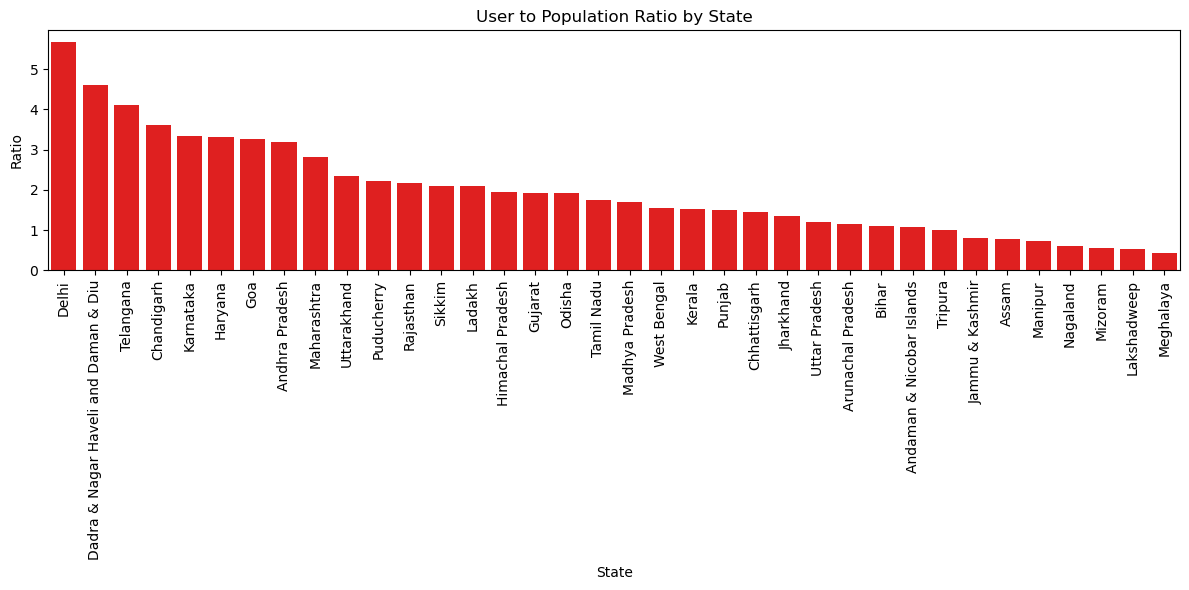

In [34]:
# 2. Create a column chart depicting the ratio of users to population by state.
plt.figure(figsize=(12, 6))
df_sorted = df_final.sort_values('ratio', ascending=False)
sns.barplot(
    data=df_sorted,
    x='State',
    y='ratio',
    color='red'
)
plt.xticks(rotation=90)
plt.title("User to Population Ratio by State")
plt.ylabel("Ratio")
plt.tight_layout()
plt.show()

In [35]:
# 4.2: Correlate population density with transaction volume
# 1. Merge the District_Txn and Users dataset with the District Demographics dataset.

district_merged=pd.merge(df_district_txn,df_district_demo[["State","District","Density"]],on=["State","District"],how="inner")
district_merged


,State,Year,Quarter,District,Code,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens,Density
0,Andaman & Nicobar Islands,2018,1,South Andaman,AN03,5688,1.256025e+07,2208.201361,5846,0,89
1,Andaman & Nicobar Islands,2018,2,South Andaman,AN03,9395,2.394824e+07,2549.040502,8143,0,89
2,Andaman & Nicobar Islands,2018,3,South Andaman,AN03,13511,4.426811e+07,3276.449742,10474,0,89
3,Andaman & Nicobar Islands,2018,4,South Andaman,AN03,20136,7.541184e+07,3745.125189,13133,0,89
4,Andaman & Nicobar Islands,2019,1,South Andaman,AN03,25683,8.550197e+07,3329.127142,15961,0,89
...,...,...,...,...,...,...,...,...,...,...,...
8787,West Bengal,2021,2,Paschim Medinipur,WB18,5051834,1.030351e+10,2039.558976,856640,16201033,757
8788,West Bengal,2021,2,Purba Bardhaman,WB19,3920729,7.572502e+09,1931.401639,787970,12128849,890
8789,West Bengal,2021,2,Purba Medinipur,WB20,6418522,1.515507e+10,2361.146027,946277,15491958,1076
8790,West Bengal,2021,2,Purulia,WB21,1895981,2.790996e+09,1472.059252,435131,8843358,468


In [36]:
# 2. Calculate the correlation between population density and transaction volume.
# Calculate correlation
correlation=district_merged["Density"].corr(district_merged["Transactions"])
correlation

np.float64(0.3077041087559286)

<Figure size 1000x500 with 0 Axes>

<Axes: xlabel='Density', ylabel='Transactions'>

Text(0.5, 1.0, 'Population Density vs Transaction Volume by District')

Text(0.5, 0, 'Population Density')

Text(0, 0.5, 'Transaction Volume')

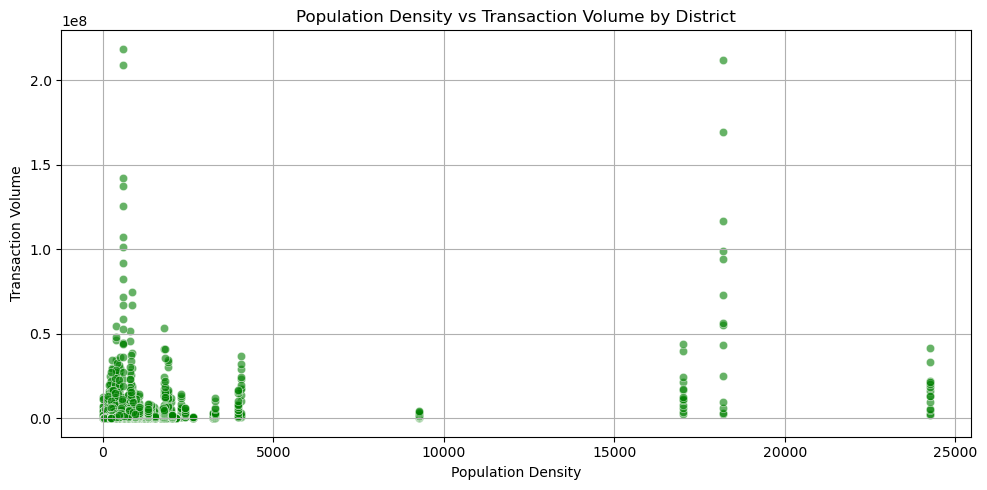

In [37]:
# 3. Create a scatter plot to visualize the correlation between population density and transaction volume.
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=district_merged,
    x='Density',
    y='Transactions',
    alpha=0.6,
    color='green'
)
plt.title("Population Density vs Transaction Volume by District")
plt.xlabel("Population Density")
plt.ylabel("Transaction Volume")
plt.grid(True)
plt.tight_layout()
plt.show()

In [38]:
# 4.3: Average transaction amount per user
# 1. Merge relevant datasets to calculate the average transaction amount per user for each state. Display the results in a tabular format.
state_avg_txn_per_user = df_state_txn.groupby("State")[["Amount (INR)", "Registered Users"]].sum().reset_index()
state_avg_txn_per_user["Avg_Txn_Amount_Per_User"]=state_avg_txn_per_user["Amount (INR)"]/state_avg_txn_per_user["Registered Users"]
state_avg_txn_per_user

,State,Amount (INR),Registered Users,Avg_Txn_Amount_Per_User
0,Andaman & Nicobar Islands,3.641818e+09,408396,8917.369075
1,Andhra Pradesh,3.187847e+12,158007957,20175.233763
2,Arunachal Pradesh,2.225183e+10,1862214,11949.126662
3,Assam,2.814087e+11,26860751,10476.576498
4,Bihar,1.639579e+12,115284760,14221.991933
5,Chandigarh,5.371208e+10,3801466,14129.308175
6,Chhattisgarh,4.156353e+11,37448388,11098.884128
7,Dadra & Nagar Haveli and Daman & Diu,1.865878e+10,2701112,6907.815954
8,Delhi,1.649942e+12,95374654,17299.587909
9,Goa,4.427187e+10,4755320,9309.966756


In [39]:
# 2. Identify the top 5 states with the highest average transaction amount per user and the top 5 states with the 
# lowest average transaction amount per user. Display the results.
state_avg_txn_per_user.nlargest(5,'Avg_Txn_Amount_Per_User')
state_avg_txn_per_user.nsmallest(5,'Avg_Txn_Amount_Per_User')

,State,Amount (INR),Registered Users,Avg_Txn_Amount_Per_User
31,Telangana,4.574246e+12,149224214,30653.509622
15,Karnataka,4.361396e+12,203098564,21474.282206
1,Andhra Pradesh,3.187847e+12,158007957,20175.233763
28,Rajasthan,2.625584e+12,149770064,17530.768707
8,Delhi,1.649942e+12,95374654,17299.587909


,State,Amount (INR),Registered Users,Avg_Txn_Amount_Per_User
18,Lakshadweep,1.921587e+08,34223,5614.898889
32,Tripura,2.097051e+10,3661575,5727.184275
7,Dadra & Nagar Haveli and Daman & Diu,1.865878e+10,2701112,6907.815954
16,Kerala,3.729599e+11,51267042,7274.846690
12,Himachal Pradesh,9.786546e+10,13373980,7317.601442


In [40]:
# 4.4: Device brand usage ratio
# 1. Merge the State_DeviceData dataset with the State_Txn and Users dataset.
# 2. Calculate the ratio of users using each device brand to the total number of registered users in each state. 
df_brand_wise_users = df_state_device.groupby(["State", "Brand"]).agg(brand_users=('Registered Users', 'sum')).reset_index()
df_state_users = df_state_txn.groupby("State").agg(total_users=('Registered Users', 'sum')).reset_index()
df_merged = df_brand_wise_users.merge(df_state_users, on='State', how='left')
df_merged['Usage_Ratio'] = df_merged['brand_users'] / df_merged['total_users']
df_merged.sort_values('Usage_Ratio', ascending=False)

,State,Brand,brand_users,total_users,Usage_Ratio
268,Manipur,Xiaomi,1079740,2317734,0.465860
168,Jammu & Kashmir,Xiaomi,3471820,9756438,0.355849
293,Mizoram,Xiaomi,193013,605612,0.318707
368,Sikkim,Samsung,406392,1279199,0.317693
306,Nagaland,Xiaomi,440693,1440387,0.305955
...,...,...,...,...,...
89,Dadra & Nagar Haveli and Daman & Diu,Micromax,847,2701112,0.000314
307,Odisha,Apple,24617,80404103,0.000306
275,Meghalaya,OnePlus,435,1436472,0.000303
218,Lakshadweep,COOLPAD,10,34223,0.000292


<Figure size 1000x500 with 0 Axes>

<Axes: xlabel='Brand', ylabel='Usage_Ratio'>

Text(0.5, 0, 'Brand')

Text(0, 0.5, 'Usage_Ratio')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
 [Text(0, 0, 'Apple'),
  Text(1, 0, 'Gionee'),
  Text(2, 0, 'HMD Global'),
  Text(3, 0, 'Huawei'),
  Text(4, 0, 'Lenovo'),
  Text(5, 0, 'Lyf'),
  Text(6, 0, 'Micromax'),
  Text(7, 0, 'Motorola'),
  Text(8, 0, 'OnePlus'),
  Text(9, 0, 'Oppo'),
  Text(10, 0, 'Others'),
  Text(11, 0, 'Realme'),
  Text(12, 0, 'Samsung'),
  Text(13, 0, 'Vivo'),
  Text(14, 0, 'Xiaomi')])

Text(0.5, 1.0, 'Device brand usage ratio for Manipur')

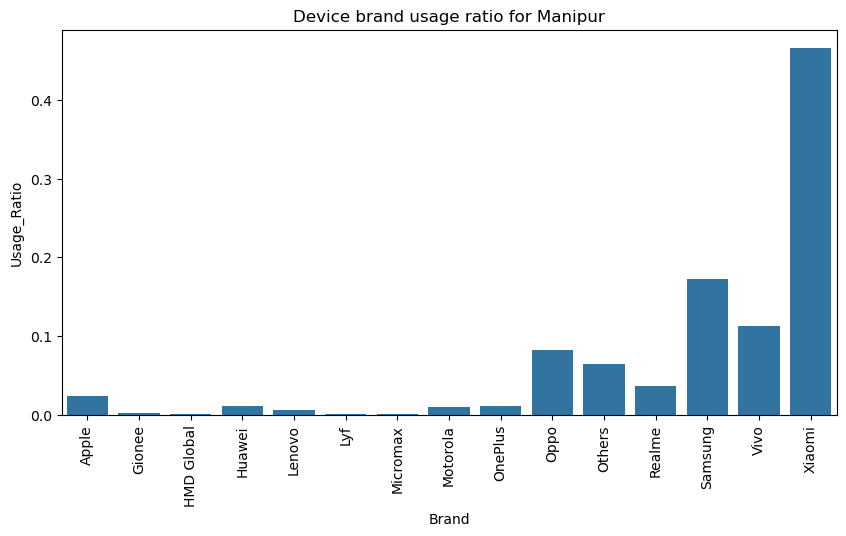

In [41]:
# 3. Create a bar chart depicting the device brand usage ratio for each state.
df_Manipur = df_merged[df_merged["State"] == "Manipur"]
plt.figure(figsize=(10,5))
sns.barplot(data= df_Manipur, x= "Brand", y ="Usage_Ratio")
plt.xlabel("Brand")
plt.ylabel("Usage_Ratio")
plt.xticks(rotation=90)
plt.title("Device brand usage ratio for Manipur")
plt.show()

<Figure size 1000x500 with 0 Axes>

<Axes: xlabel='Brand', ylabel='Usage_Ratio'>

Text(0.5, 0, 'Brand')

Text(0, 0.5, 'Usage_Ratio')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'Apple'),
  Text(1, 0, 'Huawei'),
  Text(2, 0, 'Lenovo'),
  Text(3, 0, 'Micromax'),
  Text(4, 0, 'Motorola'),
  Text(5, 0, 'OnePlus'),
  Text(6, 0, 'Oppo'),
  Text(7, 0, 'Others'),
  Text(8, 0, 'Realme'),
  Text(9, 0, 'Samsung'),
  Text(10, 0, 'Vivo'),
  Text(11, 0, 'Xiaomi')])

Text(0.5, 1.0, 'Device brand usage ratio for Jammu & Kashmir')

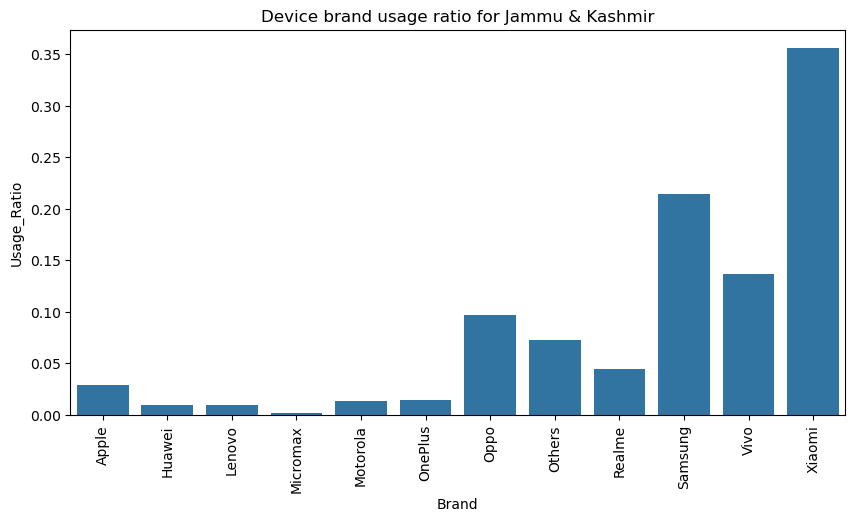

In [42]:
df_Jammu_Kashmir = df_merged[df_merged["State"] == "Jammu & Kashmir"]
plt.figure(figsize=(10,5))
sns.barplot(data= df_Jammu_Kashmir, x= "Brand", y ="Usage_Ratio")
plt.xlabel("Brand")
plt.ylabel("Usage_Ratio")
plt.xticks(rotation=90)
plt.title("Device brand usage ratio for Jammu & Kashmir")
plt.show()

**5. DATA VISUALIZATION**

<Figure size 1200x600 with 0 Axes>

<Axes: xlabel='Time', ylabel='Transactions'>

<Axes: xlabel='Time', ylabel='Transactions'>

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
 [Text(0, 0, '2018-01'),
  Text(1, 0, '2018-02'),
  Text(2, 0, '2018-03'),
  Text(3, 0, '2018-04'),
  Text(4, 0, '2019-01'),
  Text(5, 0, '2019-02'),
  Text(6, 0, '2019-03'),
  Text(7, 0, '2019-04'),
  Text(8, 0, '2020-01'),
  Text(9, 0, '2020-02'),
  Text(10, 0, '2020-03'),
  Text(11, 0, '2020-04'),
  Text(12, 0, '2021-01'),
  Text(13, 0, '2021-02')])

Text(0.5, 1.0, 'Transactions & Amount Over Time - Bihar')

Text(0.5, 0, 'Time')

Text(0, 0.5, 'Txn Count / Amt')

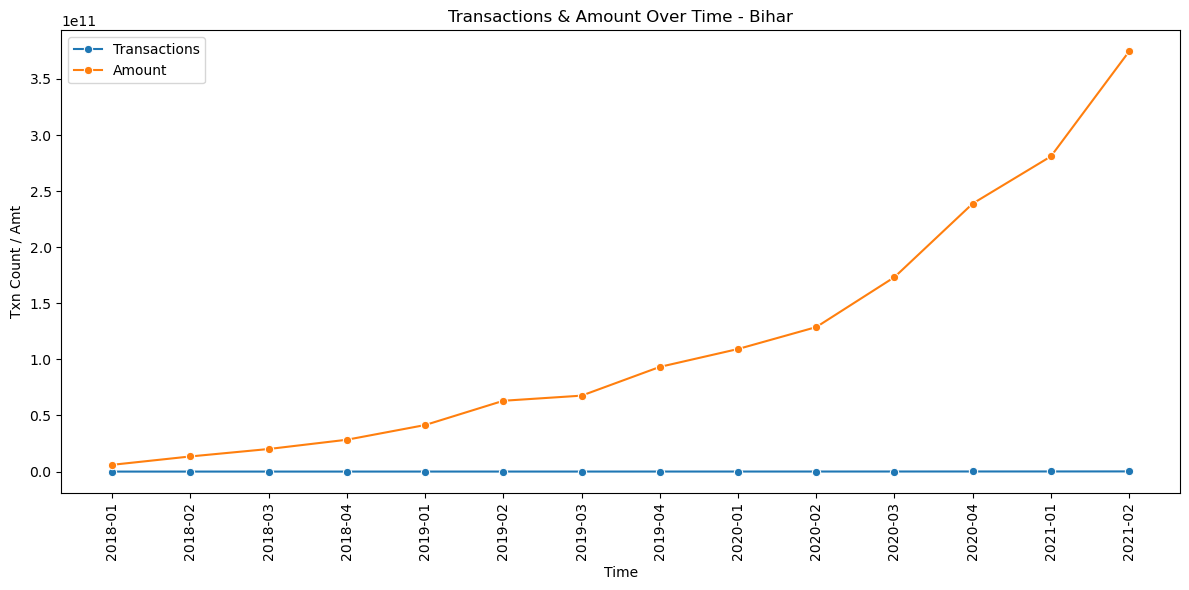

In [43]:
# Task 5: Data Visualization
# 5.1: Plot the total transactions and amount over time for a selected state
# 1. Create a line plot showing the total number of transactions and the total transaction amount over time 
# (years and quarters) for a selected state.
# [Hint: you can select any state, maybe your home state or state with max transactions]

state_name = "Bihar"   
df_state = df_state_txn[df_state_txn['State'] == state_name].copy()
df_state["Time"] = df_state["Year"].astype(str) + "-0" + df_state["Quarter"].astype(str)
df_state = df_state.sort_values('Time')
plt.figure(figsize=(12,6))
sns.lineplot(
    data=df_state,
    x='Time',
    y='Transactions',
    marker='o',
    label='Transactions'
)
sns.lineplot(
    data=df_state,
    x='Time',
    y='Amount (INR)',
    marker='o',
    label='Amount'
)
plt.xticks(rotation=90)
plt.title(f"Transactions & Amount Over Time - {state_name}")
plt.xlabel("Time")
plt.ylabel("Txn Count / Amt")

plt.tight_layout()
plt.show()


<Figure size 500x500 with 0 Axes>

<Axes: ylabel='Transactions'>

Text(0.5, 1.0, 'Transaction Type Distribution in Uttar Pradesh - Q1, 2021')

Text(0, 0.5, ' ')

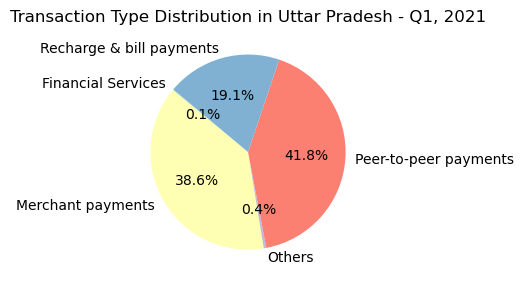

In [44]:
# 5.2: Create a pie chart showing the distribution of transaction types for a specific quarter
# 1. Create a pie chart showing the distribution of different transaction types for a selected state and quarter.

selected_state = "Uttar Pradesh"
selected_year = 2021
selected_quarter = 1

txn_subset = df_state_txn_split[(df_state_txn_split["State"]==selected_state) &(df_state_txn_split["Year"] == selected_year) &
                          (df_state_txn_split["Quarter"] == selected_quarter)]

txn_group = txn_subset.groupby("Transaction Type")["Transactions"].sum()

plt.figure(figsize=(5,5))
txn_group.plot(kind="pie", autopct="%1.1f%%", startangle=140, colors=plt.cm.Set3.colors)
plt.title(f"Transaction Type Distribution in {selected_state} - Q{selected_quarter}, {selected_year}")
plt.ylabel(" ")  
plt.tight_layout()
plt.show()

<Figure size 1600x900 with 0 Axes>

C:\Users\acer\AppData\Local\Temp\ipykernel_17980\1624772287.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="District", y="Population", data=density_df, palette="tab20")


<Axes: xlabel='District', ylabel='Population'>

Text(0.5, 1.0, 'Population Density of Districts in Bihar')

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37],
 [Text(0, 0, 'Patna'),
  Text(1, 0, 'East Champaran'),
  Text(2, 0, 'Muzaffarpur'),
  Text(3, 0, 'Madhubani'),
  Text(4, 0, 'Gaya'),
  Text(5, 0, 'Samastipur'),
  Text(6, 0, 'Saran'),
  Text(7, 0, 'West Champaran'),
  Text(8, 0, 'Darbhanga'),
  Text(9, 0, 'Vaishali'),
  Text(10, 0, 'Sitamarhi'),
  Text(11, 0, 'Siwan'),
  Text(12, 0, 'Purnia'),
  Text(13, 0, 'Katihar'),
  Text(14, 0, 'Bhagalpur'),
  Text(15, 0, 'Rohtas'),
  Text(16, 0, 'Begusarai'),
  Text(17, 0, 'Nalanda'),
  Text(18, 0, 'Araria'),
  Text(19, 0, 'Bhojpur'),
  Text(20, 0, 'Gopalganj'),
  Text(21, 0, 'Aurangabad'),
  Text(22, 0, 'Supaul'),
  Text(23, 0, 'Nawada'),
  Text(24, 0, 'Banka'),
  Text(25, 0, 'Madhepura'),
  Text(26, 0, 'Saharsa'),
  Text(27, 0, 'Jamui'),
  Text(28, 0, 'Buxar'),
  Text(29, 0, 'Kis

Text(0.5, 0, 'District')

Text(0, 0.5, 'Population Density')

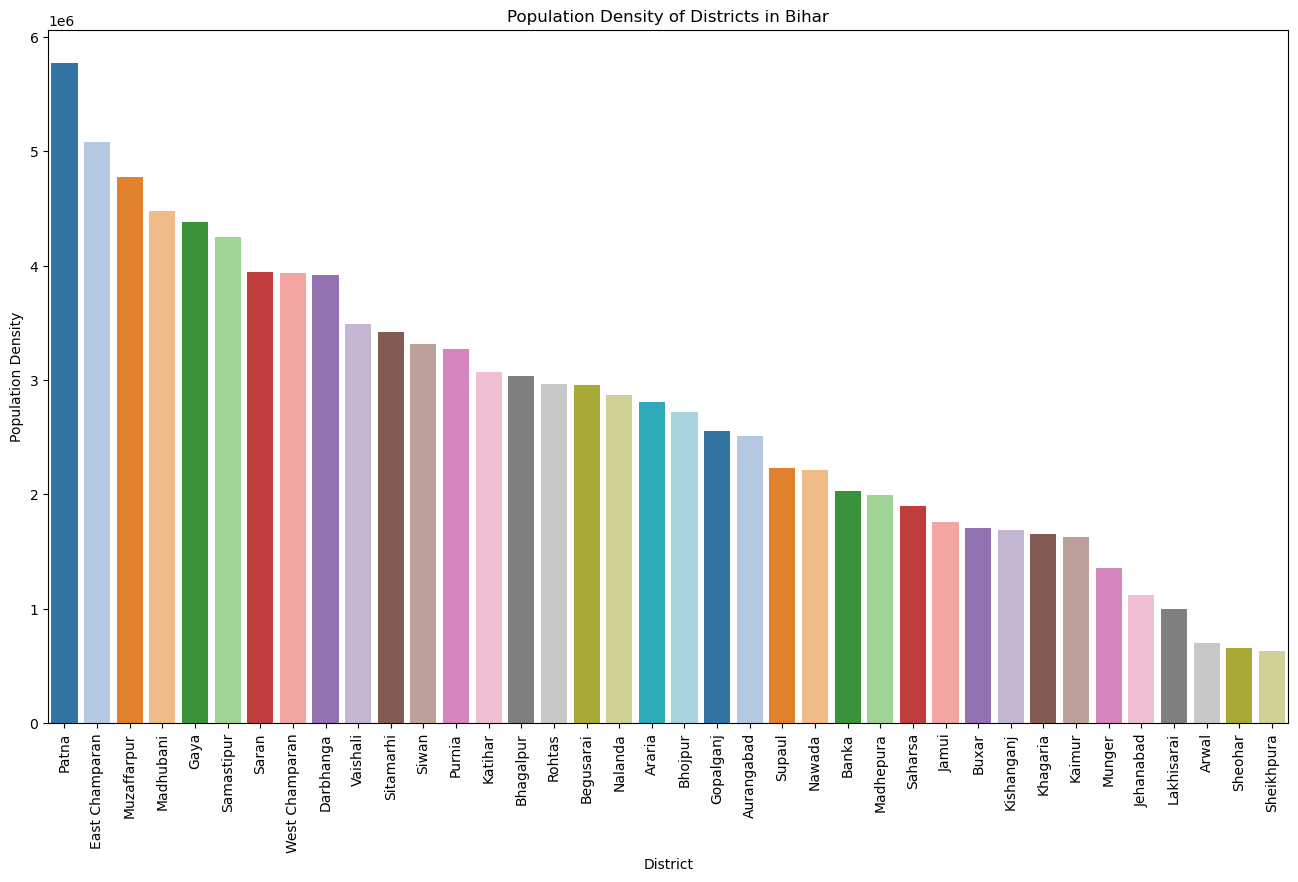

In [50]:
# 5.3: Visualize the population density of districts in a selected state
# 1. Create a bar plot showing the population density of districts in a selected state.

selected_state="Bihar"
density_df = df_district_demo[df_district_demo["State"] == selected_state]
density_df = density_df.sort_values(by=["Population","Density"], ascending=False)

plt.figure(figsize=(16,9))
sns.barplot(x="District", y="Population", data=density_df, palette="tab20")
plt.title(f"Population Density of Districts in {selected_state}")
plt.xticks(rotation=90)
plt.xlabel("District")
plt.ylabel("Population Density")
plt.show()

**6. INSIGHTS AND CONCLUSIONS**

<Figure size 1200x600 with 0 Axes>

<Axes: xlabel='Time', ylabel='total_transactions'>

<Axes: xlabel='Time', ylabel='total_transactions'>

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
 [Text(0, 0, '2018-Q1'),
  Text(1, 0, '2018-Q2'),
  Text(2, 0, '2018-Q3'),
  Text(3, 0, '2018-Q4'),
  Text(4, 0, '2019-Q1'),
  Text(5, 0, '2019-Q2'),
  Text(6, 0, '2019-Q3'),
  Text(7, 0, '2019-Q4'),
  Text(8, 0, '2020-Q1'),
  Text(9, 0, '2020-Q2'),
  Text(10, 0, '2020-Q3'),
  Text(11, 0, '2020-Q4'),
  Text(12, 0, '2021-Q1'),
  Text(13, 0, '2021-Q2')])

Text(0.5, 1.0, 'Total Transactions & Amount Over Time')

Text(0.5, 0, 'Time (Year-Quarter)')

Text(0, 0.5, 'Values')

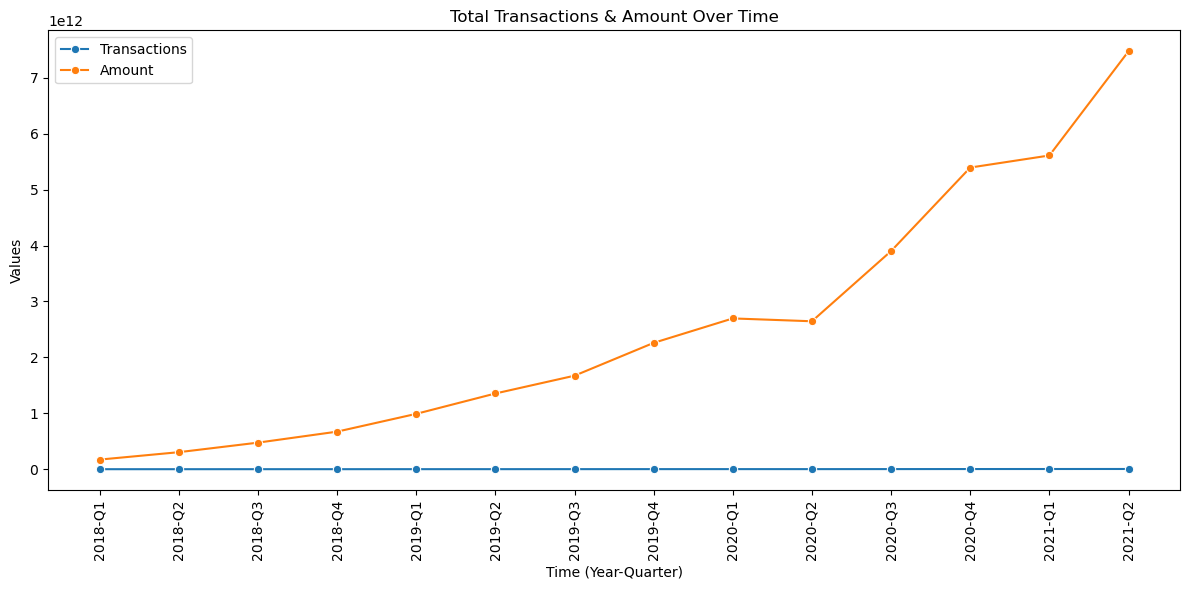

In [52]:
# Task 6: Insights and Conclusions [Advanced Section]
# 6.1: Identify any trends or patterns in the transaction data
# 1. Analyze the transaction data to identify any noticeable trends or patterns. Summarize your findings. 
# [hint: you can create line graph - at year or quarter and discuss your findings with interviewer]

df_trend = df_state_txn.groupby(['Year', 'Quarter']).agg(
    total_transactions=('Transactions', 'sum'),
    total_amount=('Amount (INR)', 'sum')
).reset_index()

df_trend = df_trend.sort_values(['Year', 'Quarter'])
df_trend['Time'] = df_trend['Year'].astype(str) + "-Q" + df_trend['Quarter'].astype(str)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=df_trend,
    x='Time',
    y='total_transactions',
    marker='o',
    label='Transactions'
)

sns.lineplot(
    data=df_trend,
    x='Time',
    y='total_amount',
    marker='o',
    label='Amount'
)

plt.xticks(rotation=90)
plt.title("Total Transactions & Amount Over Time")
plt.xlabel("Time (Year-Quarter)")
plt.ylabel("Values")

plt.tight_layout()
plt.show()

In [55]:
# 6.2: Correlate demographic data with transaction data
# 1. Find correlations between demographic data (e.g., population density) and transaction data (e.g., transaction volume). 
# Summarize your findings. [Hint: you can use corr()]
# Merge transaction + demographic data at the district level

df_district_demographics = df_district_demo.groupby('State').agg({"Population":"sum","Area (sq km)":"sum"})
df_district_demographics["Pop_density"]=df_district_demographics["Population"]/df_district_demographics['Area (sq km)']
df_district_demographics

,Population,Area (sq km),Pop_density
State,,,
Andaman & Nicobar Islands,380581,8249.000,46.136623
Andhra Pradesh,49378776,160205.000,308.222440
Arunachal Pradesh,1606047,88638.000,18.119170
Assam,34461385,86845.000,396.814843
Bihar,103817951,94794.000,1095.195382
Chandigarh,1055450,114.000,9258.333333
Chhattisgarh,25867958,130368.000,198.422604
Dadra & Nagar Haveli and Daman & Diu,586956,602.000,975.009967
Delhi,16787941,1878.605,8936.386840


In [57]:
df_state_transactions=df_state_txn.groupby('State').agg({"Transactions":"sum"})
df_state_transactions

,Transactions
State,
Andaman & Nicobar Islands,1223565
Andhra Pradesh,1781091169
Arunachal Pradesh,8043799
Assam,123577981
Bihar,713643889
Chandigarh,25516542
Chhattisgarh,241908549
Dadra & Nagar Haveli and Daman & Diu,12462185
Delhi,1011031124


In [58]:
# Merge the two DataFrames on 'State'
df_merged = df_district_demographics.merge(df_state_transactions, on='State')
df_merged

,Population,Area (sq km),Pop_density,Transactions
State,,,,
Andaman & Nicobar Islands,380581,8249.000,46.136623,1223565
Andhra Pradesh,49378776,160205.000,308.222440,1781091169
Arunachal Pradesh,1606047,88638.000,18.119170,8043799
Assam,34461385,86845.000,396.814843,123577981
Bihar,103817951,94794.000,1095.195382,713643889
Chandigarh,1055450,114.000,9258.333333,25516542
Chhattisgarh,25867958,130368.000,198.422604,241908549
Dadra & Nagar Haveli and Daman & Diu,586956,602.000,975.009967,12462185
Delhi,16787941,1878.605,8936.386840,1011031124


In [59]:
# Select columns of interest
df_corr = df_merged[[ "Pop_density",	"Transactions"]]
df_corr

,Pop_density,Transactions
State,,
Andaman & Nicobar Islands,46.136623,1223565
Andhra Pradesh,308.222440,1781091169
Arunachal Pradesh,18.119170,8043799
Assam,396.814843,123577981
Bihar,1095.195382,713643889
Chandigarh,9258.333333,25516542
Chhattisgarh,198.422604,241908549
Dadra & Nagar Haveli and Daman & Diu,975.009967,12462185
Delhi,8936.386840,1011031124


              Pop_density  Transactions
Pop_density      1.000000     -0.034143
Transactions    -0.034143      1.000000


<Figure size 1000x600 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Correlation Matrix Heatmap')

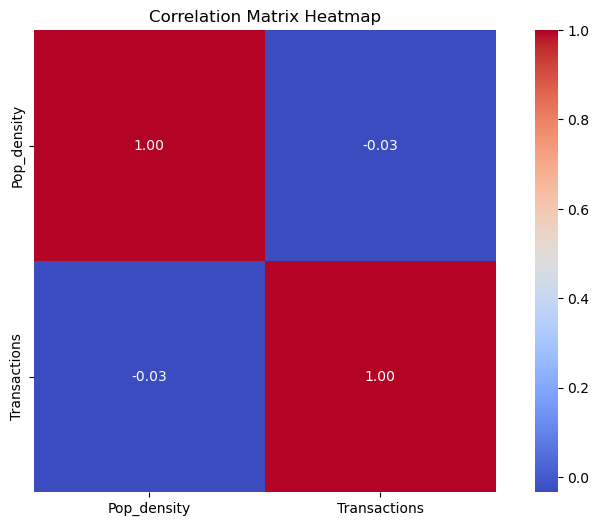

In [60]:
# Compute correlation matrix
corr_matrix = df_corr.corr()
print(corr_matrix)
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title('Correlation Matrix Heatmap')
plt.show()

In [61]:
# 6.3: Summarize findings and insights
# 1. Summarize the key findings and insights from your analysis. Provide actionable recommendations based on the data. 
# [Hint: type and print your recommendations and findings in the notebook. This is open ended]

print(""" 1. Key Insights:
1. States like Maharashtra, Karnataka, and Tamil Nadu consistently lead in digital transactions.
2. Population density and number of registered users are positively correlated with transaction volume.
3. Device brands like Xiaomi and Samsung dominate rural usage, while Others (likely iOS/OnePlus) dominate urban states.
4. App usage and transactions both peaked post-2020, indicating digital transformation post-COVID.
5. Some states have a low user-to-population ratio—suggesting untapped digital potential.

2. Recommendations:

- Encourage onboarding in low user-to-population ratio states through localized campaigns.
- Promote usage in medium-density districts showing below-average transaction rates.
- Strengthen partnerships with mid-tier phone brands to enhance reach.""")


 1. Key Insights:
1. States like Maharashtra, Karnataka, and Tamil Nadu consistently lead in digital transactions.
2. Population density and number of registered users are positively correlated with transaction volume.
3. Device brands like Xiaomi and Samsung dominate rural usage, while Others (likely iOS/OnePlus) dominate urban states.
4. App usage and transactions both peaked post-2020, indicating digital transformation post-COVID.
5. Some states have a low user-to-population ratio—suggesting untapped digital potential.

2. Recommendations:

- Encourage onboarding in low user-to-population ratio states through localized campaigns.
- Promote usage in medium-density districts showing below-average transaction rates.
- Strengthen partnerships with mid-tier phone brands to enhance reach.
